# Human-aligned cheat detector (ALLIE embeddings) — **multi-cheat sweep (2-class, 6 bins)**

This notebook trains a simple **MLP** to classify move outcomes into **2 classes**:

- `y=0`: human move
- `y=1`: cheated move

For each **cheat model** (and an extra **ALL** mixture column), we:

1. Build a 2-class dataset from `move_before`, `move_uci` and `move_{cheat_model}`.
2. Train with early stopping & LR scheduling on **validation cheat-class F1**.
3. Calibrate a **decision threshold** for cheat class on validation to maximize cheat F1.
4. Evaluate on **TEST** per rating-bin (6 bins) and **ALL**.

Artifacts are saved under `OUT_DIR`:
- `models/<cheat_name>/<run_id>/model.pt` + `meta.json`
- `curves/<cheat_name>/<run_id>.csv`
- `tables/metrics__<metric>.csv`
- `tables/selected_models.csv`


In [1]:
# === Imports / seeds ===
from __future__ import annotations

import json
import math
import os
import random
import subprocess
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Dict, List, Tuple

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.metrics import classification_report

# Repro
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)


DEVICE: cuda


In [2]:
# === spec ===

# hard-code bins and their order
BIN_NAMES: List[str] = [
    "lt_1200",
    "1200-1400",
    "1400-1600",
    "1600-1800",
    "1800-2000",
    "2000-2200",
]
BIN_NAME_TO_IDX: Dict[str, int] = {b: i for i, b in enumerate(BIN_NAMES)}

# Model name -> allowed bin indices.
# The cheat MOVE column is assumed to be: f"move_{model_name}".
CHEAT_MODEL_TO_BIN_IDXS: Dict[str, List[int]] = {
    "stockfish_1":   list(range(6)),
    "stockfish_5":   list(range(6)),
    "stockfish_9":   list(range(6)),
    "stockfish_11":  list(range(6)),
    "stockfish_15":  list(range(6)),
    "lc0_1":         list(range(6)),
    "lc0_10":        list(range(6)),
    "lc0_100":       list(range(6)),
}

CHEAT_NAMES = list(CHEAT_MODEL_TO_BIN_IDXS.keys())
CHEAT_MOVE_COLS = [f"move_{name}" for name in CHEAT_NAMES]

# --- Experiment knobs ---
EXPR_CFG: Dict[str, Any] = {
    "split_col": "split_by_player",  # "split_by_player" | "split_by_games"
    "rating_bin_col": "rating_bin",

    "human_move_col": "move_uci",

    # internal val split from TRAIN rows (game-level split, per bin)
    "val_frac": 0.1,
}

# Required columns
CSV_COLS = [
    "half_move",
    "player_color",
    "is_used",
    EXPR_CFG["split_col"],
    EXPR_CFG["rating_bin_col"],
    EXPR_CFG["human_move_col"],
    *CHEAT_MOVE_COLS,
]

NPZ_COLS = [EXPR_CFG["human_move_col"], *CHEAT_MOVE_COLS]

# --- Training defaults (per run) ---
TRAIN_CFG: Dict[str, Any] = {
    "epochs": 500,
    "early_stop_patience": 20
}

DEFAULT_FIXED_SPECS: Dict[str, Dict[str, Any]] = {
    #"mlp_001": {"hidden_dim": 1024, "act": "GELU", "norm": "batch", "drop": 0.1, "lr": 3e-4, "weight_decay": 3e-5},
    "mlp_002": {"hidden_dim": 256,  "act": "GELU", "norm": "batch", "drop": 0.0, "lr": 3e-4, "weight_decay": 3e-4},
    #"mlp_003": {"hidden_dim": 64,   "act": "GELU", "norm": "layer", "drop": 0.1, "lr": 3e-4, "weight_decay": 3e-8},
}

# How to pick the best run among the architectures (per cheat model)
# Main objective: maximize F1 of cheat class, using a validation-calibrated threshold.
# SELECT_BEST_BY = "val_f1_best"

# Threshold grid for cheat class calibration (val only)
THR_GRID = np.array([0.5])

In [3]:
# === Paths / outputs ===

def get_repo_root_git() -> Path:
    p = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()
    return Path(p)

REPO_ROOT = get_repo_root_git()
print("REPO_ROOT:", REPO_ROOT)

# ---- Dataset ----
CSV_PATH = REPO_ROOT / "data/processed/6bins_small/04_final_dataset.csv"
EMB_NPZ = REPO_ROOT / "data/processed/13bins_small/04_embs_allie_2500_full.npz"

# ---- Outputs ----
OUT_DIR = REPO_ROOT / "new_notebooks/new_reports/03_2cls_6bins" / "allie_2500_for_trasnfer"
(OUT_DIR / "models").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "curves").mkdir(parents=True, exist_ok=True)
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)

print("CSV_PATH:", CSV_PATH)
print("EMB_NPZ :", EMB_NPZ)
print("OUT_DIR :", OUT_DIR)


REPO_ROOT: /home/jovyan/artem/humanlike
CSV_PATH: /home/jovyan/artem/humanlike/data/processed/6bins_small/04_final_dataset.csv
EMB_NPZ : /home/jovyan/artem/humanlike/data/processed/13bins_small/04_embs_allie_2500_full.npz
OUT_DIR : /home/jovyan/artem/humanlike/new_notebooks/new_reports/03_2cls_6bins/allie_2500_for_trasnfer


## Prepare dataset

In [4]:
# === Load data + sanity check ===

if not CSV_PATH.exists():
    raise FileNotFoundError(f"CSV not found: {CSV_PATH}")
if not Path(EMB_NPZ).exists():
    raise FileNotFoundError(f"NPZ not found: {EMB_NPZ}")

df = pd.read_csv(CSV_PATH, index_col=0)  # CSV index stores the NPZ row id
df["npz_row"] = df.index

missing = [c for c in CSV_COLS if c not in df.columns]
if missing:
    raise KeyError(f"Missing required columns ({len(missing)}): {missing}")

# Validate bin names are exactly the fixed set.
bins_in_data = df[EXPR_CFG["rating_bin_col"]].unique()
if sorted(bins_in_data) != sorted(BIN_NAMES):
    raise ValueError(
        "Rating bins mismatch.\n"
        f"Expected exactly: {BIN_NAMES}\n"
        f"Found: {bins_in_data}"
    )

# Add stable bin index (0..5)
df["bin_idx"] = df[EXPR_CFG["rating_bin_col"]].map(BIN_NAME_TO_IDX)
print(f"CSV cols: {len(df.columns)}")

# Load NPZ keys (cheap) and keep the file handle for arrays.
npz = np.load(EMB_NPZ)
npz_keys = set(npz.files)

missing_npz = [c for c in NPZ_COLS if c not in npz_keys]
if missing_npz:
    raise KeyError(f"Missing embeddings in NPZ ({len(missing_npz)}): {missing_npz[:10]} ...")
print(f"NPZ keys: {len(npz_keys)}")

CSV cols: 247
NPZ keys: 57


In [5]:
df.head(5)

,player,game_id,rating_bin,split_by_player,split_by_games,player_color,player_elo,opponent_elo,time_control,half_move,...,eval_character_Smalldoc_2254,eval_character_alkhawaja111_2217,eval_character_fuegodejavu_2215,eval_character_jozarov_2323,eval_character_lindenice_2272,eval_character_nrm18_2369,eval_character_oberschlumpf_2261,eval_character_rmnp_2284,npz_row,bin_idx
853,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,853,5
854,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,854,5
855,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,3,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,855,5
856,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,856,5
857,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,857,5


In [6]:
# === Common row mask ===

print("is_used:", df["is_used"].value_counts(dropna=False).to_dict())

# df_filtered
df_f = df.loc[df["is_used"] == True].reset_index(drop=True)

is_used: {False: 657080, True: 417207}


In [7]:
df_f.head(5)

,player,game_id,rating_bin,split_by_player,split_by_games,player_color,player_elo,opponent_elo,time_control,half_move,...,eval_character_Smalldoc_2254,eval_character_alkhawaja111_2217,eval_character_fuegodejavu_2215,eval_character_jozarov_2323,eval_character_lindenice_2272,eval_character_nrm18_2369,eval_character_oberschlumpf_2261,eval_character_rmnp_2284,npz_row,bin_idx
0,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,21,...,6.0,6.0,6.0,-21.0,18.0,-11.0,6.0,-21.0,873,5
1,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,23,...,31.0,31.0,46.0,8.0,31.0,31.0,31.0,8.0,875,5
2,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,25,...,35.0,35.0,-9.0,35.0,35.0,35.0,35.0,35.0,877,5
3,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,27,...,-390.0,-312.0,-28.0,-28.0,-390.0,-28.0,-390.0,-28.0,879,5
4,A3_LTC,9EayTTaI,2000-2200,train,train,white,2079,2167,180+0,29,...,-365.0,-365.0,-365.0,-365.0,-365.0,-365.0,-365.0,-365.0,881,5


In [8]:
def split_train_val_by_player_per_bin(
    df_f: pd.DataFrame,
    *,
    split_col: str,
    bin_idx_col: str,
    player_col: str,
    bin_names: List[str],
    val_frac: float,
    seed: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Row-level train/val split by players within each bin (using split_col == 'train')
    """
    split = df_f[split_col].to_numpy()
    is_train = (split == "train")
    is_test = (split == "test")
    bin_idx = df_f[bin_idx_col].to_numpy()

    rng = np.random.default_rng(seed)
    train_row_idxs: List[np.ndarray] = []
    val_row_idxs: List[np.ndarray] = []

    for b in range(len(bin_names)):
        bin_train_rows = np.flatnonzero(is_train & (bin_idx == b))
        bin_players = df_f.loc[bin_train_rows, player_col].to_numpy()
        unique_players = np.unique(bin_players)

        n_val_players = max(1, int(round(val_frac * len(unique_players))))
        val_players = unique_players[rng.permutation(len(unique_players))[:n_val_players]]

        is_val_row = np.isin(bin_players, val_players)
        val_row_idxs.append(bin_train_rows[is_val_row])
        train_row_idxs.append(bin_train_rows[~is_val_row])

    train_rows = np.concatenate(train_row_idxs)
    val_rows = np.concatenate(val_row_idxs)
    test_rows = np.flatnonzero(is_test)
    return train_rows, val_rows, test_rows

In [9]:
# === splits (player-level val per rating bin) ===

train_rows, val_rows, test_rows = split_train_val_by_player_per_bin(
    df_f,
    split_col=EXPR_CFG["split_col"],
    bin_idx_col="bin_idx",
    player_col="player",
    bin_names=BIN_NAMES,
    val_frac=EXPR_CFG["val_frac"],
    seed=SEED,
)

print("Row splits:", {"train": train_rows.size, "val": val_rows.size, "test": test_rows.size})

Row splits: {'train': 300346, 'val': 33794, 'test': 83067}


In [10]:
# === Build embeddings aligned with df_filtered ===

npz_rows = df_f["npz_row"].to_numpy(dtype=np.int64)

split_norm = df_f[EXPR_CFG["split_col"]].to_numpy()
bin_idx = df_f["bin_idx"].to_numpy(dtype=np.int64)

HUMAN_MOVE_COL = EXPR_CFG["human_move_col"]

# (N, 1024) float32
emb_human = np.asarray(npz[HUMAN_MOVE_COL])[npz_rows].astype(np.float32, copy=False)
move_human = df_f[HUMAN_MOVE_COL].to_numpy()

# Preload cheat moves + embeddings
move_cheat_dict = {name: df_f[f"move_{name}"].to_numpy() for name in CHEAT_NAMES}
emb_cheat_dict = {name: np.asarray(npz[f"move_{name}"])[npz_rows].astype(np.float32, copy=False) for name in CHEAT_NAMES}

print("emb_human:", emb_human.shape, emb_human.dtype)
print("Loaded emb_cheat:", {k: v.shape for k, v in emb_cheat_dict.items()})

emb_human: (417207, 1024) float32
Loaded emb_cheat: {'stockfish_1': (417207, 1024), 'stockfish_5': (417207, 1024), 'stockfish_9': (417207, 1024), 'stockfish_11': (417207, 1024), 'stockfish_15': (417207, 1024), 'lc0_1': (417207, 1024), 'lc0_10': (417207, 1024), 'lc0_100': (417207, 1024)}


In [11]:
# === Build 'ALL' cheat mixture (row-level) as a normal "cheat model" ===

# Creates:
#   - df_f["move_ALL"]  (UCI string)
#   - move_cheat["ALL"] (np.ndarray[str])
#   - emb_cheat["ALL"]      (np.ndarray float32, shape like emb_human)
#   - CHEAT_MODEL_TO_BIN_IDXS["ALL"] (allowed bins)

rng = np.random.default_rng(SEED)

src_cheat_all = np.empty(len(df_f), dtype=object)
move_cheat_all = np.empty(len(df_f), dtype=object)
emb_cheat_all = np.empty_like(emb_human, dtype=np.float32)

for i in range(len(df_f)):
    b_idx = int(bin_idx[i])
    allowed_names = [name for name in CHEAT_NAMES if b_idx in CHEAT_MODEL_TO_BIN_IDXS[name]]
    if not allowed_names:
        raise ValueError(f"No allowed cheat models for bin_idx={b_idx} at row i={i}")
    random_name = str(rng.choice(allowed_names))
    src_cheat_all[i] = random_name
    move_cheat_all[i] = move_cheat_dict[random_name][i]
    emb_cheat_all[i] = emb_cheat_dict[random_name][i]

df_f["cheat_all_src"] = pd.Series(src_cheat_all, dtype="string")
df_f["move_ALL"] = pd.Series(move_cheat_all, dtype="string")

# Register ALL in the common containers so it behaves like any other cheat model.
move_cheat_dict["ALL"] = df_f["move_ALL"].to_numpy()
emb_cheat_dict["ALL"] = emb_cheat_all

# "ALL" usable everywhere
CHEAT_MODEL_TO_BIN_IDXS["ALL"] = list(range(len(BIN_NAMES)))

# Keep ordering stable for later loops.
if "ALL" not in CHEAT_NAMES:
    CHEAT_NAMES = CHEAT_NAMES + ["ALL"]


In [12]:
print(f"{move_cheat_dict=}\n")

print(f"{emb_human.shape=}\n")

print(f"{emb_cheat_dict=}\n")

move_cheat_dict={'stockfish_1': array(['b2b4', 'b2b4', 'b2b4', ..., 'f2d4', 'h6h5', 'h6h5'],
      shape=(417207,), dtype=object), 'stockfish_5': array(['a2a4', 'f1e1', 'f1e1', ..., 'f2d4', 'g3h2', 'f4h4'],
      shape=(417207,), dtype=object), 'stockfish_9': array(['c3c4', 'd3e2', 'c1e3', ..., 'f2b6', 'g3e3', 'f4h4'],
      shape=(417207,), dtype=object), 'stockfish_11': array(['b2b4', 'f1e1', 'b2b4', ..., 'f2b6', 'g3f4', 'f4h4'],
      shape=(417207,), dtype=object), 'stockfish_15': array(['b2b4', 'f1e1', 'b2b4', ..., 'f2e3', 'g7h7', 'f4h4'],
      shape=(417207,), dtype=object), 'lc0_1': array(['b2b4', 'b2b4', 'b2b4', ..., 'g3f4', 'g3f4', 'f4e3'],
      shape=(417207,), dtype=object), 'lc0_10': array(['b2b4', 'b2b4', 'f1e1', ..., 'f2d4', 'g3e3', 'h6h5'],
      shape=(417207,), dtype=object), 'lc0_100': array(['b2b4', 'f1e1', 'b2b4', ..., 'f2d4', 'g3e3', 'h6h5'],
      shape=(417207,), dtype=object), 'ALL': array(['b2b4', 'b2b4', 'b2b4', ..., 'f2d4', 'g3f4', 'f4h4'],
      shape=(417

## Training

In [13]:
# === Dataset builder (2-class) ===
# Classes:
# 0 = human move
# 1 = cheat move

def build_xy_for_rows(
    rows: np.ndarray,
    *,
    emb_human: np.ndarray,
    emb_cheat: np.ndarray,
    move_human: np.ndarray,
    move_cheat: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    
    mh = move_human[rows]
    mc = move_cheat[rows]

    if pd.isna(mh).any() or pd.isna(mc).any():
        bad = np.flatnonzero(pd.isna(mh) | pd.isna(mc))[:10]
        raise ValueError(f"NA in moves for rows (showing up to 10 offsets): {bad.tolist()}")

    X_human = emb_human[rows]
    y_human = np.zeros_like(rows)

    X_cheat = emb_cheat[rows]
    y_cheat = np.ones_like(rows)
    X = np.concatenate([X_human, X_cheat], axis=0).astype(np.float32)
    y = np.concatenate([y_human, y_cheat], axis=0).astype(np.int64)
    return X, y

In [14]:
# === Model builder ===

def build_mlp(
    input_dim: int,
    out_dim: int,
    *,
    hidden_dim: int,
    act: str,
    norm: str | None,
    drop: float,
) -> nn.Module:
    layers: List[nn.Module] = [nn.Linear(input_dim, hidden_dim)]

    if norm == "layer":
        layers.append(nn.LayerNorm(hidden_dim))
    elif norm == "batch":
        layers.append(nn.BatchNorm1d(hidden_dim))
    elif norm is None:
        pass
    else:
        raise ValueError(f"Unknown norm: {norm}")

    if act == "ReLU":
        layers.append(nn.ReLU())
    elif act == "GELU":
        layers.append(nn.GELU())
    elif act == "LeakyReLU":
        layers.append(nn.LeakyReLU(0.1))
    else:
        raise ValueError(f"Unknown activation: {act}")

    if drop > 0:
        layers.append(nn.Dropout(drop))

    layers.append(nn.Linear(hidden_dim, out_dim))
    return nn.Sequential(*layers)


In [15]:
@torch.no_grad()
def predict_proba(model: nn.Module, X: torch.Tensor) -> np.ndarray:
    """p(cheat=1) for binary model that outputs a single logit per sample."""
    model.eval()
    logits = model(X)                # (N,)
    logits = logits.view(-1)         # (N,)
    p = torch.sigmoid(logits)
    return p.detach().cpu().numpy()  # (N,)

def apply_threshold(p_pos: np.ndarray, thr: float):
    return (p_pos >= float(thr)).astype(np.int64)

def best_threshold_for_f1_macro(
    p_pos: np.ndarray,
    y_true: np.ndarray,
    thr_grid: np.ndarray,
) -> tuple[float, float]:
    best_thr = 0.5
    best_f1 = -1.0

    for thr in thr_grid:
        y_pred = apply_threshold(p_pos, thr)
        f1 = float(f1_score(y_true, y_pred, average="macro"))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1


def compute_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "micro_f1": float(f1_score(y_true, y_pred, average="micro")),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro")),
        "cheat_precision": float(precision_score(y_true, y_pred, average="binary",  pos_label=1)),
        "cheat_recall": float(recall_score(y_true, y_pred, average="binary", pos_label=1)),
        "cheat_f1": float(f1_score(y_true, y_pred, average="binary", pos_label=1)),
    }


In [16]:
def train_one(
    *,
    X_train_t: torch.Tensor,   # on DEVICE
    y_train_t: torch.Tensor,   # on DEVICE
    pos_weight: torch.Tensor,
    X_val_t: torch.Tensor,     # on DEVICE
    y_val: np.ndarray,         # on CPU
    spec: dict[str, Any],
    out_dir: Path,
    tag: str,
) -> dict[str, Any]:

    out_dir.mkdir(parents=True, exist_ok=True)

    in_dim = int(X_train_t.shape[1])
    model = build_mlp(
        in_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    opt = torch.optim.AdamW(
        model.parameters(),
        lr=float(spec["lr"]),
        weight_decay=float(spec["weight_decay"]),
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt,
        mode="min",
        factor=0.1,
        patience=10,
    )

    # ensure float targets for BCE
    y_train_f = y_train_t.to(dtype=torch.float32)
    y_val_t = torch.from_numpy(y_val).to(DEVICE, dtype=torch.float32)

    best = {"val_loss": float("inf"), "epoch": -1, "state": None}
    curves: list[dict[str, Any]] = []
    bad = 0
    patience = int(TRAIN_CFG["early_stop_patience"])
    epochs = int(TRAIN_CFG["epochs"])

    for epoch in range(epochs):
        model.train()
        opt.zero_grad(set_to_none=True)

        logits = model(X_train_t).view(-1)  # (N,)
        loss = loss_fn(logits, y_train_f.view(-1))
        loss.backward()
        opt.step()
        train_loss = float(loss.item())

        model.eval()
        with torch.no_grad():
            val_logits = model(X_val_t).view(-1)  # (N,)
            val_loss_t = loss_fn(val_logits, y_val_t.view(-1))
            val_loss = float(val_loss_t.item())

        scheduler.step(val_loss)
        lr_now = float(opt.param_groups[0]["lr"])

        curves.append({
            "epoch": int(epoch),
            "train_loss": train_loss,
            "val_loss": val_loss,
            "lr": lr_now,
        })

        if val_loss < best["val_loss"] - 1e-6:
            best["val_loss"] = val_loss
            best["epoch"] = int(epoch)
            best["state"] = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            bad = 0
        else:
            bad += 1

        if epoch % 25 == 0:
            print(f"[{tag}] epoch={epoch} train_loss={train_loss:.4f} val_loss={val_loss:.4f} lr={lr_now:.2e}")

        if bad >= patience:
            break

    if best["state"] is None:
        raise RuntimeError("Training finished without a best state (unexpected).")

    model.load_state_dict(best["state"], strict=True)

    # Calibrate threshold on val (optimize F1 for class 1)
    with torch.no_grad():
        p_val = predict_proba(model, X_val_t)  # (N,)
    best_thr, best_val_f1 = best_threshold_for_f1_macro(p_val, y_val.astype(np.int64), THR_GRID)

    # Save
    model_path = out_dir / "model.pt"
    meta_path = out_dir / "meta.json"
    curves_path = out_dir / "curves.csv"

    torch.save(best["state"], model_path)
    meta = {
        "tag": tag,
        "spec": spec,
        "in_dim": in_dim,
        "seed": SEED,
        "best": {
            "best_epoch": int(best["epoch"]),
            "best_val_loss": float(best["val_loss"]),
            "best_thr": float(best_thr),
            "val_f1_at_best_thr": float(best_val_f1),
        },
    }
    meta_path.write_text(json.dumps(meta, indent=2, ensure_ascii=False))
    pd.DataFrame(curves).to_csv(curves_path, index=False)

    return {
        "tag": tag,
        "spec": spec,
        "best_thr": float(best_thr),
        "best_val_f1": float(best_val_f1),
        "best_epoch": int(best["epoch"]),
        "best_val_loss": float(best["val_loss"]),
        "model_path": model_path,
        "meta_path": meta_path,
        "curves_path": curves_path,
    }


In [17]:
# === Train: per cheat model ===

ALL_CHEAT_NAMES = CHEAT_NAMES  # includes "ALL"

train_results: dict[str, dict[str, dict[str, Any]]] = {}
selected: list[dict[str, Any]] = []

for cheat_name in ALL_CHEAT_NAMES:
    if cheat_name not in emb_cheat_dict or cheat_name not in move_cheat_dict:
        raise KeyError(f"Missing cheat bundle for '{cheat_name}'. "
                       f"Have emb keys: {list(emb_cheat_dict.keys())[:10]} ...")

    emb_cheat = emb_cheat_dict[cheat_name]
    move_cheat = move_cheat_dict[cheat_name]

    # Build (CPU numpy)
    X_train, y_train = build_xy_for_rows(
        train_rows,
        emb_human=emb_human,
        emb_cheat=emb_cheat,
        move_human=move_human,
        move_cheat=move_cheat,
    )

    # weights to balance classes on train
    n_pos = int((y_train == 1).sum())
    n_neg = int((y_train == 0).sum())
    pos_weight = torch.tensor([n_neg / n_pos], device=DEVICE, dtype=torch.float32)

    X_val, y_val = build_xy_for_rows(
        val_rows,
        emb_human=emb_human,
        emb_cheat=emb_cheat,
        move_human=move_human,
        move_cheat=move_cheat,
    )

    # Move once on GPU -- reused across runs/specs
    X_train_t = torch.from_numpy(X_train).to(DEVICE, dtype=torch.float32, non_blocking=True)
    y_train_t = torch.from_numpy(y_train).to(DEVICE, dtype=torch.long, non_blocking=True)
    X_val_t = torch.from_numpy(X_val).to(DEVICE, dtype=torch.float32, non_blocking=True)

    train_results[cheat_name] = {}
    for run_id, spec in DEFAULT_FIXED_SPECS.items():
        out_dir = OUT_DIR / "models" / cheat_name / run_id
        res = train_one(
            X_train_t=X_train_t,
            y_train_t=y_train_t,
            pos_weight=pos_weight,
            X_val_t=X_val_t,
            y_val=y_val,
            spec=spec,
            out_dir=out_dir,
            tag=f"{cheat_name}/{run_id}",
        )
        res["run_id"] = run_id
        res["in_dim"] = int(X_train.shape[1])
        train_results[cheat_name][run_id] = res

    # pick best spec
    best_run_id, best_res = max(
        train_results[cheat_name].items(),
        key=lambda kv: float(kv[1]["best_val_f1"]),
    )

    selected.append({
        "cheat_name": cheat_name,
        "selected_run_id": best_run_id,
        "best_val_f1": float(best_res["best_val_f1"]),
        "best_thr": float(best_res["best_thr"]),
        "model_path": str(best_res["model_path"]),
        "meta_path": str(best_res["meta_path"]),
    })

selected_df = pd.DataFrame(selected).sort_values(["cheat_name"]).reset_index(drop=True)
display(selected_df)
selected_df.to_csv(OUT_DIR / "tables" / "selected_models.csv", index=False)


[stockfish_1/mlp_002] epoch=0 train_loss=0.7139 val_loss=0.6929 lr=3.00e-04
[stockfish_1/mlp_002] epoch=25 train_loss=0.6732 val_loss=0.6767 lr=3.00e-04
[stockfish_1/mlp_002] epoch=50 train_loss=0.6667 val_loss=0.6711 lr=3.00e-04
[stockfish_1/mlp_002] epoch=75 train_loss=0.6612 val_loss=0.6678 lr=3.00e-04
[stockfish_1/mlp_002] epoch=100 train_loss=0.6547 val_loss=0.6642 lr=3.00e-04
[stockfish_1/mlp_002] epoch=125 train_loss=0.6467 val_loss=0.6605 lr=3.00e-04
[stockfish_1/mlp_002] epoch=150 train_loss=0.6375 val_loss=0.6575 lr=3.00e-04
[stockfish_1/mlp_002] epoch=175 train_loss=0.6276 val_loss=0.6559 lr=3.00e-04
[stockfish_1/mlp_002] epoch=200 train_loss=0.6181 val_loss=0.6557 lr=3.00e-05
[stockfish_5/mlp_002] epoch=0 train_loss=0.7094 val_loss=0.6934 lr=3.00e-04
[stockfish_5/mlp_002] epoch=25 train_loss=0.6759 val_loss=0.6789 lr=3.00e-04
[stockfish_5/mlp_002] epoch=50 train_loss=0.6695 val_loss=0.6736 lr=3.00e-04
[stockfish_5/mlp_002] epoch=75 train_loss=0.6631 val_loss=0.6706 lr=3.00e

,cheat_name,selected_run_id,best_val_f1,best_thr,model_path,meta_path
0,ALL,mlp_002,0.573756,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
1,lc0_1,mlp_002,0.580702,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
2,lc0_10,mlp_002,0.578247,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
3,lc0_100,mlp_002,0.578843,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
4,stockfish_1,mlp_002,0.597927,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
5,stockfish_11,mlp_002,0.577644,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
6,stockfish_15,mlp_002,0.575187,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
7,stockfish_5,mlp_002,0.589240,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...
8,stockfish_9,mlp_002,0.580753,0.5,/home/jovyan/artem/humanlike/new_notebooks/new...,/home/jovyan/artem/humanlike/new_notebooks/new...


## Evalation

In [18]:
@torch.no_grad()
def eval_one(
    *,
    model_path: Path,
    spec: dict[str, Any],
    thr: float,
    X: np.ndarray,   # CPU numpy
    y: np.ndarray,   # CPU numpy
) -> dict[str, float]:
    X_t = torch.from_numpy(X).to(DEVICE, dtype=torch.float32, non_blocking=True)

    input_dim = int(X.shape[1])
    model = build_mlp(
        input_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    probs = predict_proba(model, X_t)
    y_pred = apply_threshold(probs, thr=float(thr))
    return compute_metrics(y, y_pred)


@torch.no_grad()
def eval_one_with_pred(
    *,
    model_path: Path,
    spec: dict[str, Any],
    thr: float,
    X: np.ndarray,
    y: np.ndarray,
) -> tuple[dict[str, float], np.ndarray]:
    X_t = torch.from_numpy(X).to(DEVICE, dtype=torch.float32, non_blocking=True)

    input_dim = int(X.shape[1])
    model = build_mlp(
        input_dim,
        1,
        hidden_dim=int(spec["hidden_dim"]),
        act=str(spec["act"]),
        norm=spec["norm"],
        drop=float(spec["drop"]),
    ).to(DEVICE)

    state = torch.load(model_path, map_location="cpu")
    model.load_state_dict(state, strict=True)

    probs = predict_proba(model, X_t)
    y_pred = apply_threshold(probs, thr=float(thr))

    metrics = compute_metrics(y, y_pred)
    return metrics, y_pred

In [19]:
from sklearn.metrics import classification_report

CLASS_LABELS = [0, 1]
CLASS_NAMES = ["human", "cheat"]

def eval_table_for_cheat(cheat_name: str) -> dict[str, dict[str, float]]:
    allowed_bins_set = set(CHEAT_MODEL_TO_BIN_IDXS[cheat_name])

    row = selected_df.loc[selected_df["cheat_name"] == cheat_name].iloc[0].to_dict()
    run_id = str(row["selected_run_id"])
    res = train_results[cheat_name][run_id]
    spec = DEFAULT_FIXED_SPECS[run_id]

    emb_cheat = emb_cheat_dict[cheat_name]
    move_cheat = move_cheat_dict[cheat_name]

    out: dict[str, dict[str, float]] = {}

    # per-bin
    for b_idx, b_name in enumerate(BIN_NAMES):
        if b_idx not in allowed_bins_set:
            continue  # allowed to skip

        rows_bin = np.flatnonzero((bin_idx == b_idx) & (split_norm == "test"))
        if rows_bin.size == 0:
            raise ValueError(
                f"No TEST rows for bin='{b_name}' (idx={b_idx}) while it is allowed for cheat='{cheat_name}'."
            )

        X_test, y_test = build_xy_for_rows(
            rows_bin,
            emb_human=emb_human,
            emb_cheat=emb_cheat,
            move_human=move_human,
            move_cheat=move_cheat,
        )

        metrics, y_pred = eval_one_with_pred(
            model_path=Path(res["model_path"]),
            spec=spec,
            thr=float(res["best_thr"]),
            X=X_test,
            y=y_test,
        )
        out[b_name] = metrics

        rep = classification_report(
            y_test,
            y_pred,
            labels=CLASS_LABELS,
            target_names=CLASS_NAMES,
            digits=2,
            zero_division=0,
        )
        print(f"\n=== classification_report | cheat={cheat_name} | bin={b_name} ===\n{rep}")
        (OUT_DIR / "tables" / "classification_report").mkdir(parents=True, exist_ok=True)
        (OUT_DIR / "tables" / "classification_report" / f"{cheat_name}__{b_name}.txt").write_text(
            rep, encoding="utf-8"
        )

    # ALL rows (only bins where this cheat is allowed)
    rows_all = np.flatnonzero((split_norm == "test") & np.isin(bin_idx, list(allowed_bins_set)))
    if rows_all.size == 0:
        return out

    X_test_all, y_test_all = build_xy_for_rows(
        rows_all,
        emb_human=emb_human,
        emb_cheat=emb_cheat,
        move_human=move_human,
        move_cheat=move_cheat,
    )

    metrics_all, y_pred_all = eval_one_with_pred(
        model_path=Path(res["model_path"]),
        spec=spec,
        thr=float(res["best_thr"]),
        X=X_test_all,
        y=y_test_all,
    )
    out["ALL"] = metrics_all

    rep_all = classification_report(
        y_test_all,
        y_pred_all,
        labels=CLASS_LABELS,
        target_names=CLASS_NAMES,
        digits=2,
        zero_division=0,
    )
    print(f"\n=== classification_report | cheat={cheat_name} | bin=ALL ===\n{rep_all}")
    (OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
    (OUT_DIR / "tables" / f"classification_report__{cheat_name}__ALL.txt").write_text(
        rep_all, encoding="utf-8"
    )

    return out


ALL_ROWS = BIN_NAMES + ["ALL"]
ALL_COLS = ALL_CHEAT_NAMES  # includes "ALL"

metric_names = [
    "accuracy",
    "micro_f1",
    "macro_f1",
    "cheat_precision",
    "cheat_recall",
    "cheat_f1",
]

tables: dict[str, pd.DataFrame] = {
    m: pd.DataFrame(index=ALL_ROWS, columns=ALL_COLS, dtype=float) for m in metric_names
}

selected_cheats = set(selected_df["cheat_name"].tolist())

for cheat_name in ALL_COLS:
    if cheat_name not in selected_cheats:
        continue

    results_map = eval_table_for_cheat(cheat_name)
    for row_name, metrics in results_map.items():
        for m in metric_names:
            tables[m].loc[row_name, cheat_name] = float(metrics.get(m, np.nan))

for m in metric_names:
    print("===", m, "===")
    display(tables[m])

# optional: save tables
(OUT_DIR / "tables").mkdir(parents=True, exist_ok=True)
for m in metric_names:
    tables[m].to_csv(OUT_DIR / "tables" / f"metrics__{m}.csv", index=True)



=== classification_report | cheat=stockfish_1 | bin=lt_1200 ===
              precision    recall  f1-score   support

       human       0.60      0.68      0.64     13332
       cheat       0.63      0.55      0.59     13332

    accuracy                           0.61     26664
   macro avg       0.62      0.61      0.61     26664
weighted avg       0.62      0.61      0.61     26664


=== classification_report | cheat=stockfish_1 | bin=1200-1400 ===
              precision    recall  f1-score   support

       human       0.60      0.67      0.63     13962
       cheat       0.62      0.55      0.59     13962

    accuracy                           0.61     27924
   macro avg       0.61      0.61      0.61     27924
weighted avg       0.61      0.61      0.61     27924


=== classification_report | cheat=stockfish_1 | bin=1400-1600 ===
              precision    recall  f1-score   support

       human       0.59      0.65      0.62     13621
       cheat       0.61      0.56     

,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.613711,0.607373,0.595935,0.597960,0.592972,0.594134,0.595410,0.592372,0.590384
1200-1400,0.609297,0.599556,0.589206,0.590102,0.586807,0.588025,0.588240,0.586950,0.583441
1400-1600,0.603186,0.596248,0.584906,0.585823,0.579143,0.587292,0.586227,0.586080,0.580721
1600-1800,0.599342,0.587578,0.579247,0.577603,0.577603,0.578590,0.578407,0.578845,0.571757
1800-2000,0.594736,0.586467,0.573093,0.573884,0.569677,0.573201,0.573956,0.572913,0.566477
2000-2200,0.586779,0.575378,0.565522,0.566827,0.566380,0.561573,0.558997,0.561229,0.559993
ALL,0.600979,0.591866,0.581091,0.581807,0.578575,0.580212,0.579923,0.579484,0.575234


=== micro_f1 ===


,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.613711,0.607373,0.595935,0.597960,0.592972,0.594134,0.595410,0.592372,0.590384
1200-1400,0.609297,0.599556,0.589206,0.590102,0.586807,0.588025,0.588240,0.586950,0.583441
1400-1600,0.603186,0.596248,0.584906,0.585823,0.579143,0.587292,0.586227,0.586080,0.580721
1600-1800,0.599342,0.587578,0.579247,0.577603,0.577603,0.578590,0.578407,0.578845,0.571757
1800-2000,0.594736,0.586467,0.573093,0.573884,0.569677,0.573201,0.573956,0.572913,0.566477
2000-2200,0.586779,0.575378,0.565522,0.566827,0.566380,0.561573,0.558997,0.561229,0.559993
ALL,0.600979,0.591866,0.581091,0.581807,0.578575,0.580212,0.579923,0.579484,0.575234


=== macro_f1 ===


...

,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.630106,0.618767,0.606441,0.608707,0.598412,0.598617,0.599406,0.596264,0.597650
1200-1400,0.623483,0.610282,0.599330,0.599494,0.593288,0.592587,0.593023,0.591512,0.590156
1400-1600,0.612955,0.604897,0.591589,0.591845,0.582140,0.588837,0.587123,0.586717,0.584156
1600-1800,0.608163,0.594961,0.585025,0.582313,0.580321,0.579250,0.579071,0.579985,0.575585
1800-2000,0.602633,0.590899,0.577756,0.577906,0.571429,0.573544,0.574383,0.573034,0.567349
2000-2200,0.597305,0.584729,0.572229,0.572374,0.570759,0.563218,0.559628,0.562557,0.564603
ALL,0.612073,0.600463,0.588378,0.588344,0.582455,0.582282,0.581636,0.581307,0.579544


=== cheat_recall ===


,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.550705,0.559406,0.546580,0.548530,0.565332,0.571407,0.575308,0.572157,0.553180
1200-1400,0.551855,0.550924,0.538247,0.542902,0.552070,0.563386,0.562527,0.562025,0.546197
1400-1600,0.559944,0.555025,0.548418,0.553043,0.560899,0.578592,0.581088,0.582410,0.560311
1600-1800,0.558568,0.548703,0.545269,0.548995,0.560687,0.574425,0.574205,0.571721,0.546438
1800-2000,0.556267,0.562091,0.543108,0.548069,0.557417,0.570864,0.571079,0.572086,0.560006
2000-2200,0.532692,0.520192,0.519093,0.528503,0.535440,0.548558,0.553709,0.550618,0.524313
ALL,0.551483,0.549075,0.539865,0.544813,0.555046,0.567638,0.569432,0.568276,0.548148


=== cheat_f1 ===


,stockfish_1,stockfish_5,stockfish_9,stockfish_11,stockfish_15,lc0_1,lc0_10,lc0_100,ALL
lt_1200,0.587736,0.587591,0.574957,0.577054,0.581402,0.584696,0.587110,0.583962,0.574556
1200-1400,0.585486,0.579086,0.567148,0.569796,0.571937,0.577618,0.577373,0.576392,0.567326
1400-1600,0.585252,0.578889,0.569186,0.571786,0.571322,0.583670,0.584090,0.584555,0.571985
1600-1800,0.582311,0.570896,0.564448,0.565163,0.570335,0.576827,0.576628,0.575823,0.560633
1800-2000,0.578522,0.576135,0.559896,0.562592,0.564336,0.572201,0.572727,0.572559,0.563653
2000-2200,0.563151,0.550576,0.544368,0.549564,0.552536,0.555791,0.556653,0.556524,0.543713
ALL,0.580200,0.573620,0.563079,0.565742,0.568420,0.574867,0.575469,0.574718,0.563409


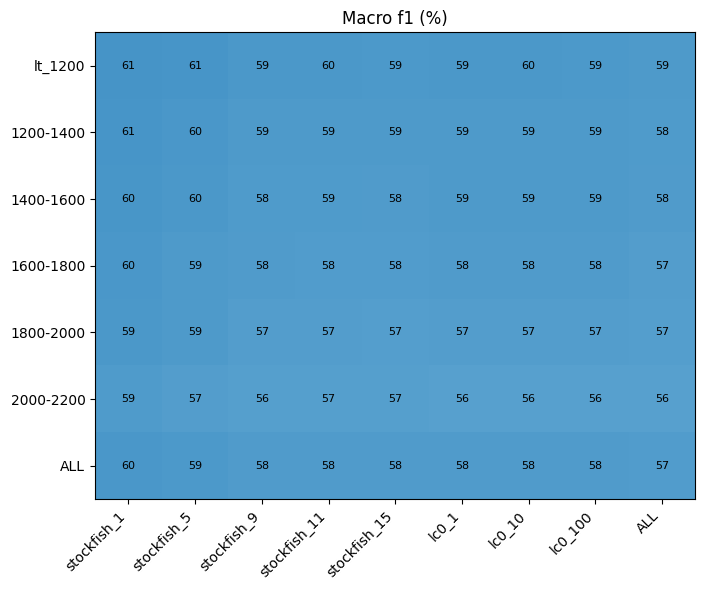

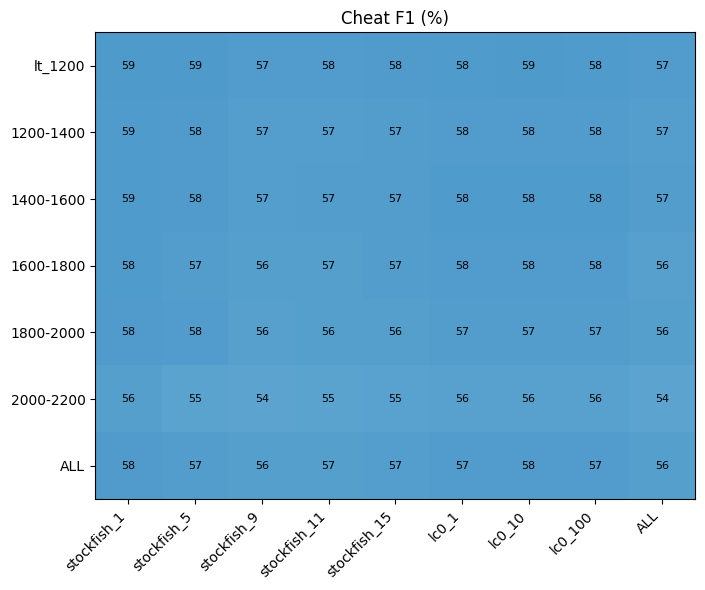

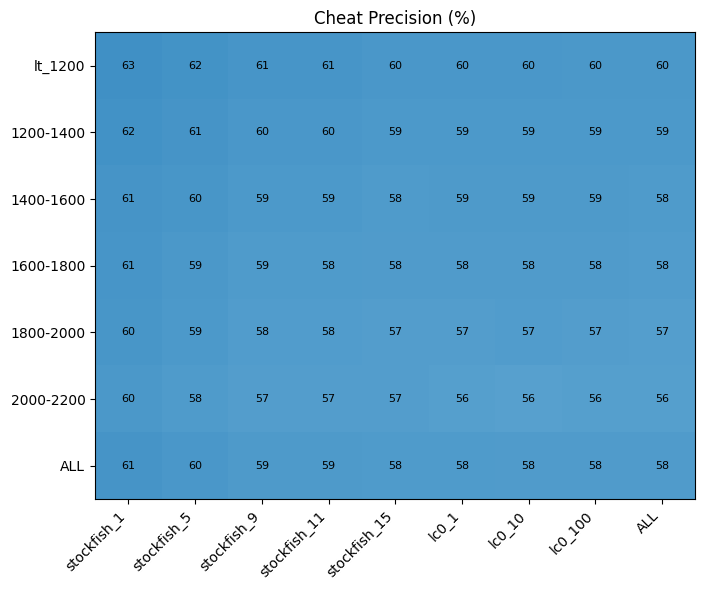

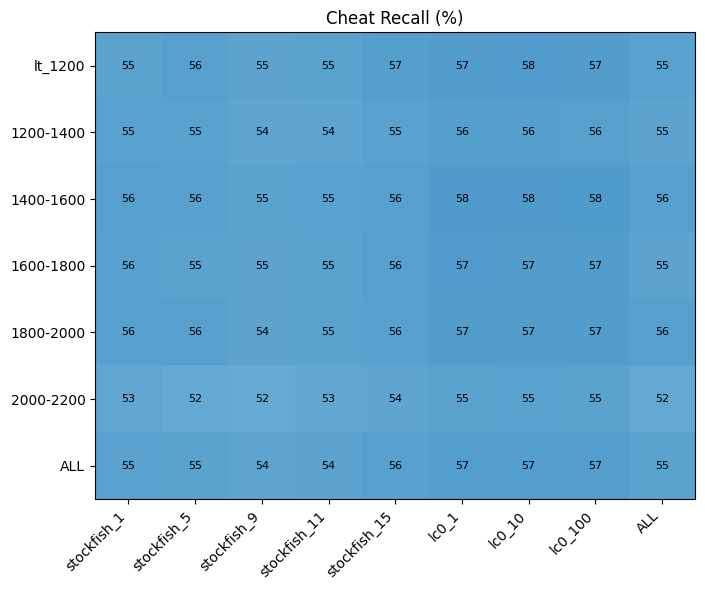

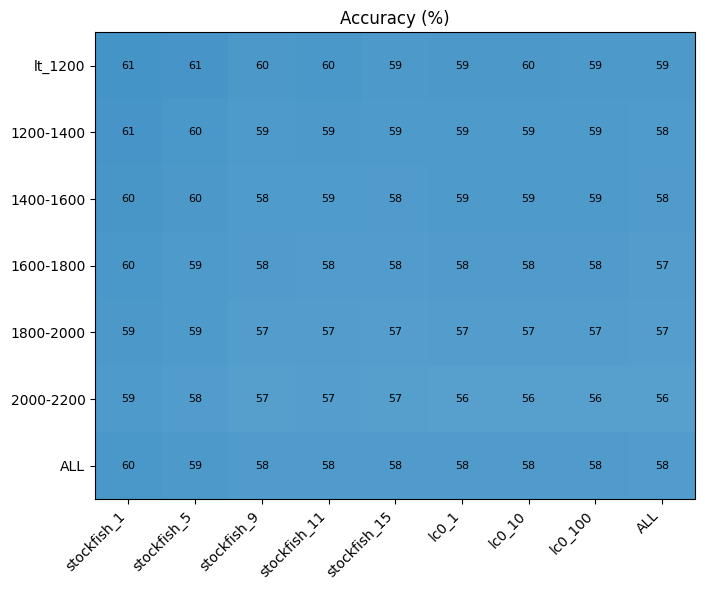

In [20]:
# === Optional: quick heatmaps ===
import matplotlib.pyplot as plt

def plot_metric_heatmap(
    tbl: pd.DataFrame,
    *,
    title: str,
    out_path: Path,
    vmin: float = 0.0,
    vmax: float = 1.0,
    figsize: tuple[int, int] = (10, 6),
    show_values: bool = True,
) -> None:
    out_path.parent.mkdir(parents=True, exist_ok=True)

    mat = tbl.to_numpy(dtype=float)

    fig, ax = plt.subplots(figsize=figsize)
    _im = ax.imshow(mat, vmin=vmin, vmax=vmax, cmap="Blues", interpolation="nearest")

    ax.set_xticks(range(tbl.shape[1]))
    ax.set_yticks(range(tbl.shape[0]))
    ax.set_xticklabels([str(c) for c in tbl.columns], rotation=45, ha="right")
    ax.set_yticklabels([str(r) for r in tbl.index])
    ax.set_title(title)

    if show_values:
        for i in range(tbl.shape[0]):
            for j in range(tbl.shape[1]):
                v = mat[i, j]
                if np.isfinite(v):
                    ax.text(j, i, f"{v*100:.0f}", ha="center", va="center", fontsize=8, color="black")

    fig.tight_layout()
    fig.savefig(out_path, dpi=200)
    plt.show()
    plt.close(fig)

# Make sure directory exists; keep it as you intended ("trash")
PLOTS_DIR = OUT_DIR / "tables" / "plots"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

plot_metric_heatmap(
    tables["macro_f1"],
    title="Macro f1 (%)",
    out_path=PLOTS_DIR / "heatmap__macro_f1.png",
    figsize=(max(10, 0.6 * len(tables["macro_f1"].columns)), max(6, 0.45 * len(tables["macro_f1"].index))),
)

plot_metric_heatmap(
    tables["cheat_f1"],
    title="Cheat F1 (%)",
    out_path=PLOTS_DIR / "heatmap__cheat_f1.png",
    figsize=(max(10, 0.6 * len(tables["cheat_f1"].columns)), max(6, 0.45 * len(tables["cheat_f1"].index))),
)

plot_metric_heatmap(
    tables["cheat_precision"],
    title="Cheat Precision (%)",
    out_path=PLOTS_DIR / "heatmap__cheat_precision.png",
    figsize=(max(10, 0.6 * len(tables["cheat_precision"].columns)), max(6, 0.45 * len(tables["cheat_precision"].index))),
)

plot_metric_heatmap(
    tables["cheat_recall"],
    title="Cheat Recall (%)",
    out_path=PLOTS_DIR / "heatmap__cheat_recall.png",
    figsize=(max(10, 0.6 * len(tables["cheat_recall"].columns)), max(6, 0.45 * len(tables["cheat_recall"].index))),
)

plot_metric_heatmap(
    tables["accuracy"],
    title="Accuracy (%)",
    out_path=PLOTS_DIR / "heatmap__accuracy.png",
    figsize=(max(10, 0.6 * len(tables["accuracy"].columns)), max(6, 0.45 * len(tables["accuracy"].index))),
)
